Consider the dataset for predicting the power yield of two plants. Work on any one plant, generation data and weather sensor data need to be combine.

1. Identify which ML model will work best on this dataset, you can use SVR, Random Forest and boosting models.
2. Also, perform EDA as well on the dataset along with data cleaning and preprocessing.
3. Use correlation matrix to identify important features from the dataset.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df_gen = pd.read_csv("Plant_1_Generation_Data - Plant_1_Generation_Data.csv")
df_weath = pd.read_csv("Plant_1_Weather_Sensor_Data - Plant_1_Weather_Sensor_Data.csv")
df_gen.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [4]:
df_gen = df_gen.drop(['SOURCE_KEY'],axis=1)
df_weath = df_weath.drop(['SOURCE_KEY'],axis=1)

In [5]:
df_gen.dtypes, df_weath.dtypes

(DATE_TIME       object
 PLANT_ID         int64
 DC_POWER       float64
 AC_POWER       float64
 DAILY_YIELD    float64
 TOTAL_YIELD    float64
 dtype: object,
 DATE_TIME               object
 PLANT_ID                 int64
 AMBIENT_TEMPERATURE    float64
 MODULE_TEMPERATURE     float64
 IRRADIATION            float64
 dtype: object)

In [6]:
# Set DATE_TIME as the index and convert it to datetime format
df_gen['DATE_TIME'] = pd.to_datetime(df_gen['DATE_TIME'], format='%d-%m-%Y %H:%M', dayfirst=True)
df_gen.set_index('DATE_TIME', inplace=True)

# Resample the data to 15-minute intervals and calculate the mean
df_gen_resampled = df_gen.resample('15T').mean().reset_index()

# Display the resampled dataframe
df_gen_resampled.head()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4135001.0,0.0,0.0,0.0,6.837223e+06
1,2020-05-15 00:15:00,4135001.0,0.0,0.0,0.0,6.837223e+06
2,2020-05-15 00:30:00,4135001.0,0.0,0.0,0.0,6.837223e+06
3,2020-05-15 00:45:00,4135001.0,0.0,0.0,0.0,6.837223e+06
4,2020-05-15 01:00:00,4135001.0,0.0,0.0,0.0,6.852802e+06


In [7]:
# Convert DATE_TIME columns to datetime format
df_gen_resampled['DATE_TIME'] = pd.to_datetime(df_gen_resampled['DATE_TIME'], format='%d-%m-%Y %H:%M:%S')
df_weath['DATE_TIME'] = pd.to_datetime(df_weath['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# Convert DATE_TIME columns to datetime format without seconds
df_gen_resampled['DATE_TIME'] = pd.to_datetime(df_gen_resampled['DATE_TIME']).dt.strftime('%Y-%m-%d %H:%M')
df_weath['DATE_TIME'] = pd.to_datetime(df_weath['DATE_TIME']).dt.strftime('%Y-%m-%d %H:%M')

# Merge the dataframes on DATE_TIME and PLANT_ID
df_combined = pd.merge(df_gen_resampled, df_weath, on=['DATE_TIME', 'PLANT_ID'])


In [8]:
df_combined['DATE_TIME'] = pd.to_datetime(df_combined['DATE_TIME'])

In [9]:
df_combined.isnull().sum()

DATE_TIME              0
PLANT_ID               0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

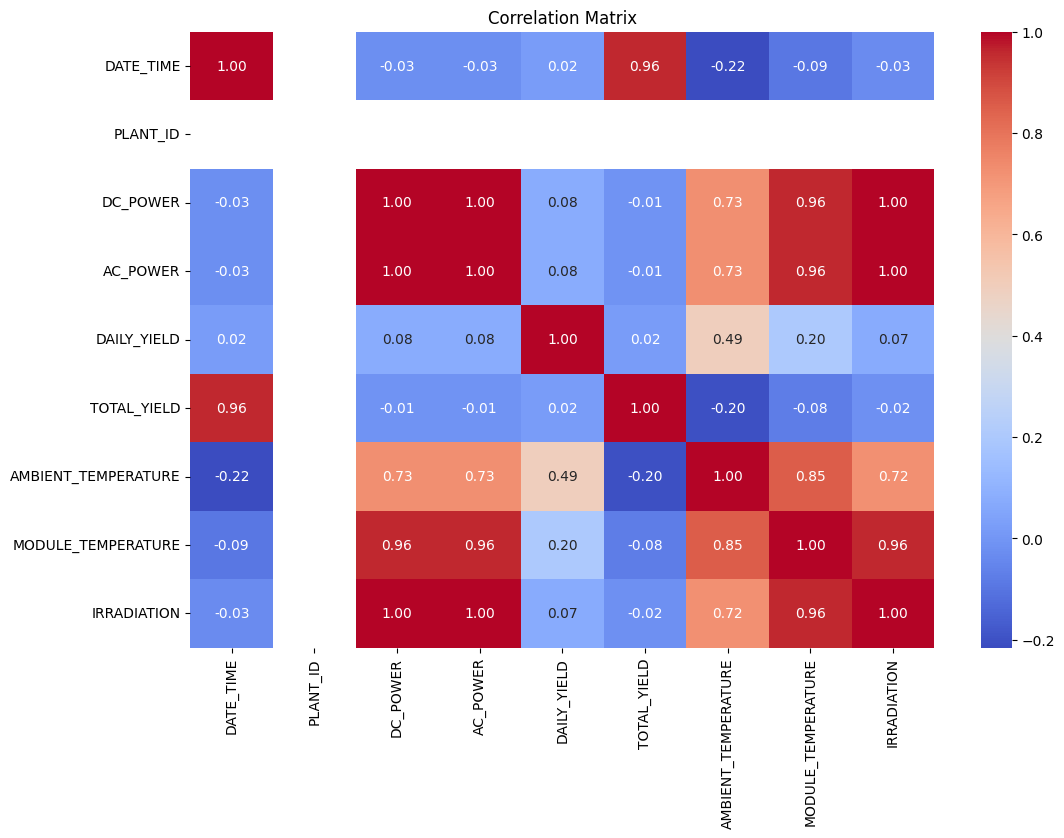

In [10]:
import seaborn as sns



# Calculate the correlation matrix
corr_matrix = df_combined.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

c:\Users\JAYANSH\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


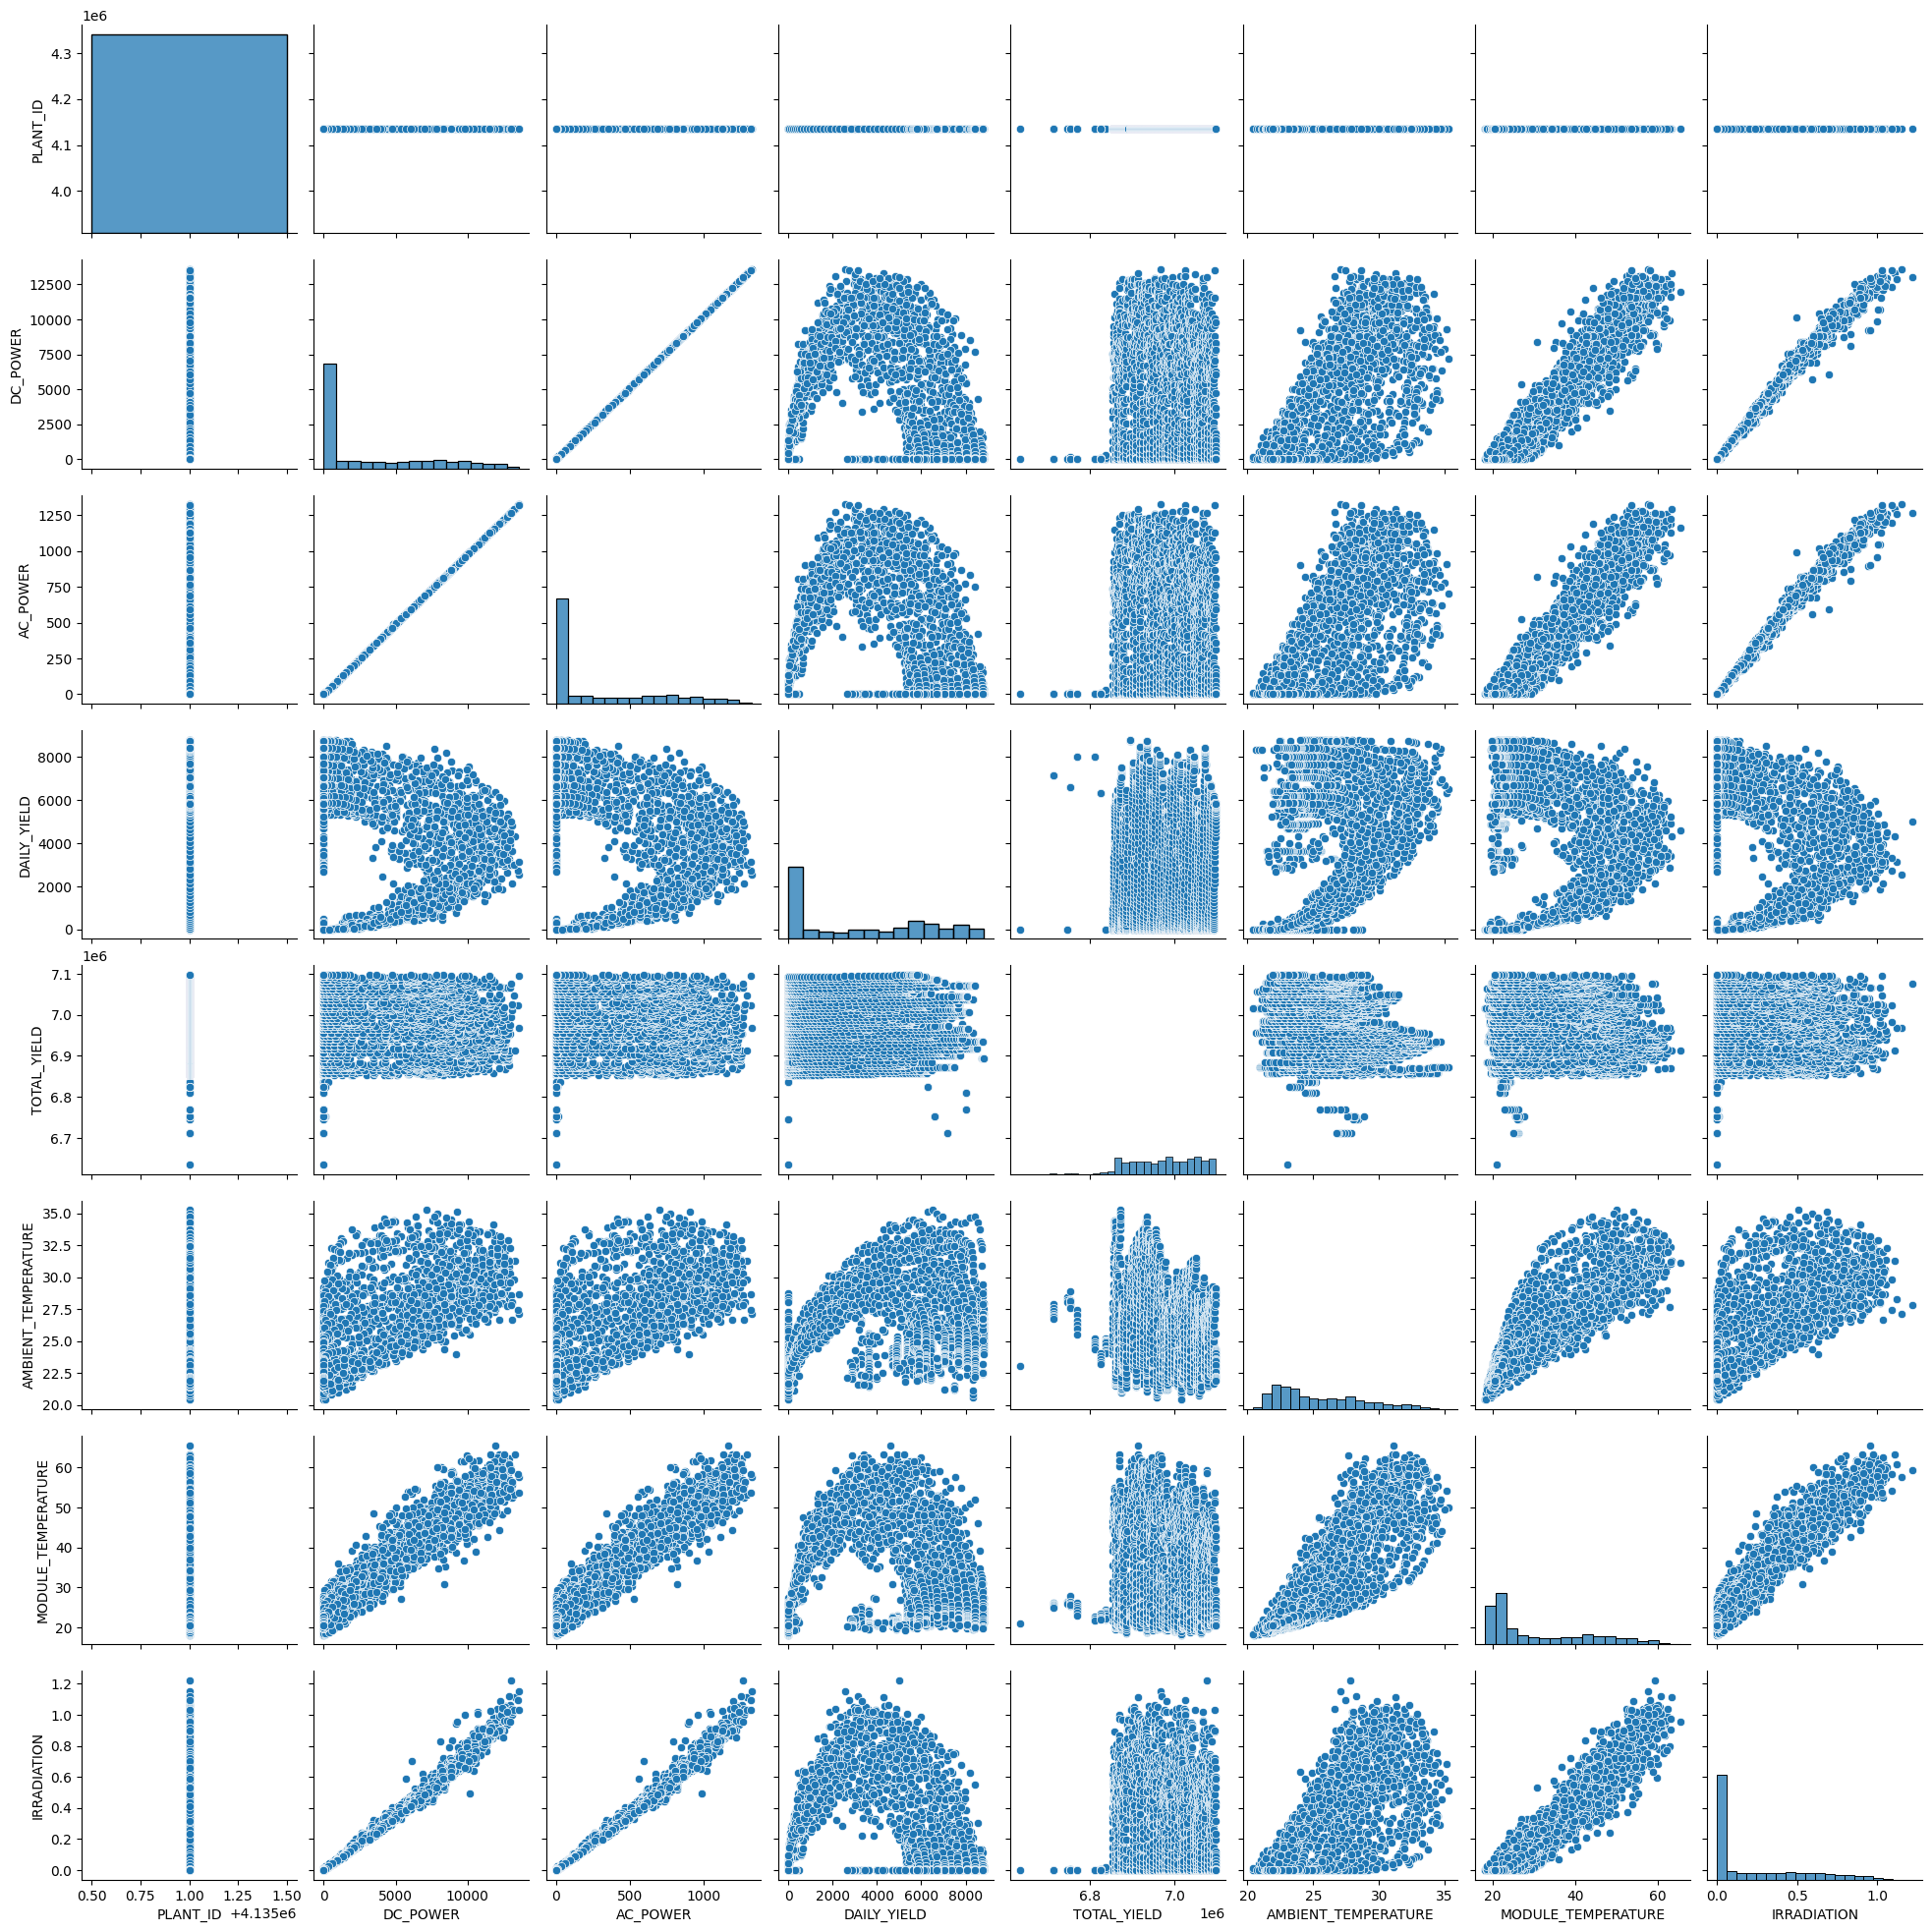

In [11]:
sns.pairplot(df_combined)
plt.show()

In [12]:
df_combined.value_counts()

DATE_TIME            PLANT_ID   DC_POWER    AC_POWER   DAILY_YIELD  TOTAL_YIELD   AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION
2020-05-15 00:00:00  4135001.0  0.000000    0.000000   0.000000     6.837223e+06  25.184316            22.857507           0.000000       1
2020-06-06 22:45:00  4135001.0  0.000000    0.000000   2868.136364  7.021257e+06  22.119533            20.250877           0.000000       1
2020-06-06 23:15:00  4135001.0  0.000000    0.000000   2868.136364  7.021257e+06  22.194932            20.219128           0.000000       1
2020-06-06 23:30:00  4135001.0  0.000000    0.000000   2868.136364  7.021257e+06  22.081917            20.148322           0.000000       1
2020-06-06 23:45:00  4135001.0  0.000000    0.000000   2659.971591  7.021257e+06  22.123830            20.200745           0.000000       1
                                                                                                                                         ..
2020-05-26 17:45:00  4135

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_combined[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]
y = df_combined['TOTAL_YIELD']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Instantiate the SVR model with RBF kernel
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

mse_svm, r2_svm


(5809021462.538945, -0.02579212645047968)

In [15]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score,classification_report

grad_boost_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
grad_boost_model.fit(X_train_scaled, y_train)
y_pred_grad_boost = grad_boost_model.predict(X_test_scaled)

mse_grad_boost = mean_squared_error(y_test, y_pred_grad_boost)
r2_grad_boost = r2_score(y_test, y_pred_grad_boost)

mse_grad_boost, r2_grad_boost

(3431955775.7633915, 0.393964502316429)

In [16]:
print(f"SVR Model - Mean Squared Error: {mse_svm}, R² Score: {r2_svm}")
print(f"Gradient Boosting Model - Mean Squared Error: {mse_grad_boost}, R² Score: {r2_grad_boost}")

SVR Model - Mean Squared Error: 5809021462.538945, R² Score: -0.02579212645047968
Gradient Boosting Model - Mean Squared Error: 3431955775.7633915, R² Score: 0.393964502316429


In [17]:
gen_1 = pd.read_csv("Plant_1_Generation_Data - Plant_1_Generation_Data.csv")
sens_1 = pd.read_csv("Plant_1_Weather_Sensor_Data - Plant_1_Weather_Sensor_Data.csv")

In [18]:
df_gen1 = gen_1.copy()
df_sens1 = sens_1.copy()

df_gen1['DATE_TIME'] = pd.to_datetime(df_gen1['DATE_TIME'],format = '%d-%m-%Y %H:%M')
df_sens1['DATE_TIME'] = pd.to_datetime(df_sens1['DATE_TIME'],format = '%Y-%m-%d %H:%M:%S')

df_plant1 = pd.merge(df_gen1.drop(columns = ['PLANT_ID']), df_sens1.drop(columns = ['PLANT_ID', 'SOURCE_KEY']), on='DATE_TIME')

In [19]:
# Adding inverter number column to the dataframe
sensor_keys = df_plant1['SOURCE_KEY'].unique()
sensor_numbers = dict(zip(sensor_keys, range(1, len(sensor_keys) + 1)))

# Add SENSOR_NUM column using map
df_plant1['SENSOR_NUM'] = df_plant1['SOURCE_KEY'].map(sensor_numbers)

# Add SENSOR_NAME column
df_plant1['SENSOR_NAME'] = df_plant1['SENSOR_NUM'].astype(str)

df_plant1['DATE_TIME'] = pd.to_datetime(df_plant1['DATE_TIME'])

# Adding separate date and time columns
df_plant1['DATE'] = df_plant1['DATE_TIME'].dt.date
df_plant1['TIME'] = df_plant1['DATE_TIME'].dt.time

# Add hours and minutes for ML models
df_plant1['HOURS'] = df_plant1['DATE_TIME'].dt.hour
df_plant1['MINUTES'] = df_plant1['DATE_TIME'].dt.minute
df_plant1['MINUTES_PASS'] = df_plant1['HOURS'] * 60 + df_plant1['MINUTES']

# Add date as string column
df_plant1['DATE_STR'] = df_plant1['DATE'].astype(str)

df_plant1.tail()

,DATE_TIME,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,SENSOR_NUM,SENSOR_NAME,DATE,TIME,HOURS,MINUTES,MINUTES_PASS,DATE_STR
68769,2020-06-17 23:45:00,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0,21.909288,20.427972,0.0,17,17,2020-06-17,23:45:00,23,45,1425,2020-06-17
68770,2020-06-17 23:45:00,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0,21.909288,20.427972,0.0,18,18,2020-06-17,23:45:00,23,45,1425,2020-06-17
68771,2020-06-17 23:45:00,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0,21.909288,20.427972,0.0,19,19,2020-06-17,23:45:00,23,45,1425,2020-06-17
68772,2020-06-17 23:45:00,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0,21.909288,20.427972,0.0,20,20,2020-06-17,23:45:00,23,45,1425,2020-06-17
68773,2020-06-17 23:45:00,zVJPv84UY57bAof,0.0,0.0,5910.000,7363272.0,21.909288,20.427972,0.0,21,21,2020-06-17,23:45:00,23,45,1425,2020-06-17


In [20]:
X = df_plant1[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION','SENSOR_NUM']]
y = df_plant1['TOTAL_YIELD']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:

grad_boost_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
grad_boost_model.fit(X_train_scaled, y_train)
y_pred_grad_boost = grad_boost_model.predict(X_test_scaled)

mse_grad_boost = mean_squared_error(y_test, y_pred_grad_boost)
r2_grad_boost = r2_score(y_test, y_pred_grad_boost)

mse_grad_boost, r2_grad_boost

(5452989555.748638, 0.9684136480181099)

In [22]:
# Calculate the R² score for the training set
y_train_pred_grad_boost = grad_boost_model.predict(X_train_scaled)
r2_train_grad_boost = r2_score(y_train, y_train_pred_grad_boost)

# Calculate the R² score for the test set
r2_test_grad_boost = r2_grad_boost  # This was already calculated in CELL INDEX: 21

print(f"Gradient Boosting Model - Train R² Score: {r2_train_grad_boost}")
print(f"Gradient Boosting Model - Test R² Score: {r2_test_grad_boost}")

Gradient Boosting Model - Train R² Score: 0.9687125809816876
Gradient Boosting Model - Test R² Score: 0.9684136480181099


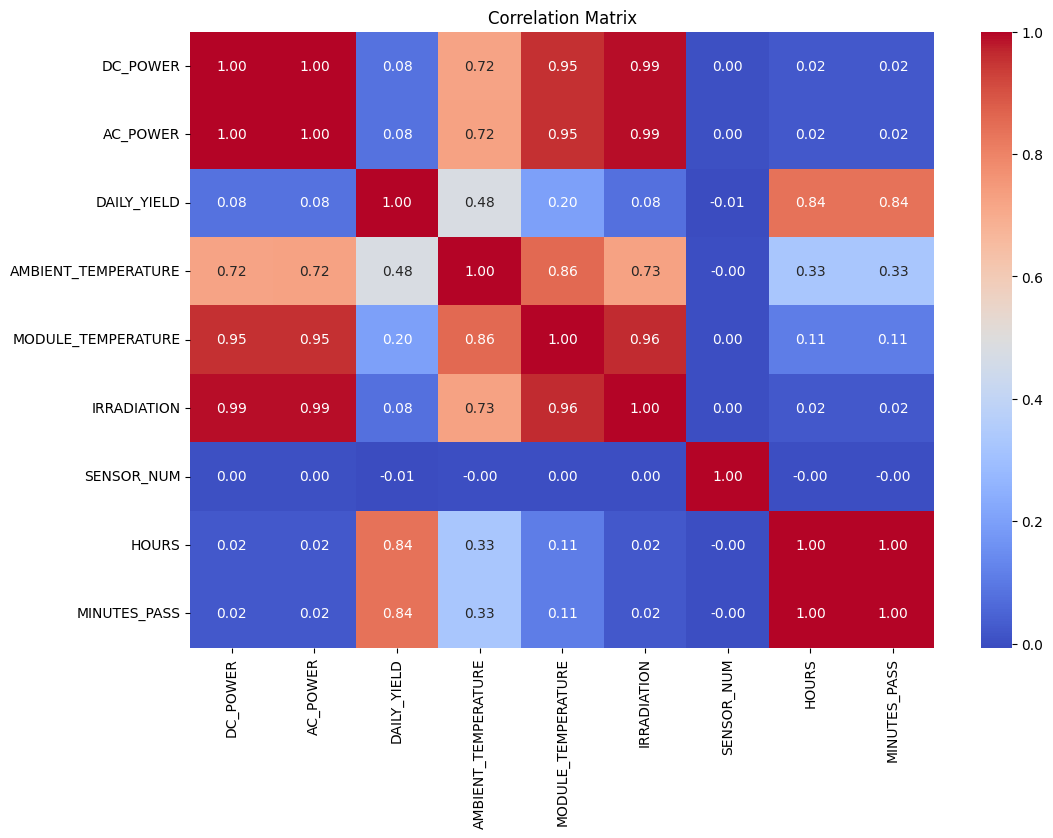

In [23]:
corr_matrix = df_plant1[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION','SENSOR_NUM','HOURS','MINUTES_PASS']].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Perform hyperparameter tuning, cross validation or regularization on the solar power dataset models as models are being overfit. Submit the code with methods implied to reduce overfitting.


In [24]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Gradient Boosting Regressor
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# Instantiate the GridSearchCV object
grid_search = GridSearchCV(estimator=GradientBoostingRegressor(random_state=42), param_grid=param_grid, cv=5, n_jobs=-1, scoring='r2')

# Fit the grid search to the data
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Score: {best_score}")

# Train the model with the best parameters
best_grad_boost_model = GradientBoostingRegressor(**best_params, random_state=42)
best_grad_boost_model.fit(X_train_scaled, y_train)

# Predict and evaluate the model
y_pred_best_grad_boost = best_grad_boost_model.predict(X_test_scaled)
mse_best_grad_boost = mean_squared_error(y_test, y_pred_best_grad_boost)
r2_best_grad_boost = r2_score(y_test, y_pred_best_grad_boost)

print(f"Best Gradient Boosting Model - Mean Squared Error: {mse_best_grad_boost}, R² Score: {r2_best_grad_boost}")

Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
Best Cross-Validation Score: 0.993217947191434
Best Gradient Boosting Model - Mean Squared Error: 1130734249.1837213, R² Score: 0.9934502405281442


In [25]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate the R² score and MSE for the training set
y_train_pred_best_grad_boost = best_grad_boost_model.predict(X_train_scaled)
r2_train_best_grad_boost = r2_score(y_train, y_train_pred_best_grad_boost)
mse_train_best_grad_boost = mean_squared_error(y_train, y_train_pred_best_grad_boost)

# Calculate the R² score and MSE for the test set
r2_test_best_grad_boost = r2_score(y_test, y_pred_best_grad_boost)
mse_test_best_grad_boost = mean_squared_error(y_test, y_pred_best_grad_boost)

print(f"Best Gradient Boosting Model - Train R² Score: {r2_train_best_grad_boost}, Train MSE: {mse_train_best_grad_boost}")
print(f"Best Gradient Boosting Model - Test R² Score: {r2_test_best_grad_boost}, Test MSE: {mse_test_best_grad_boost}")

Best Gradient Boosting Model - Train R² Score: 0.9940981060182495, Train MSE: 1023591026.2050776
Best Gradient Boosting Model - Test R² Score: 0.9934502405281442, Test MSE: 1130734249.1837213
